# Find edge projectors - circuit cluster states 2
Created 19/08/2026

Objectives:
* Iterate on [this notebook](find_edge_projectors_circuit_cluster_states.ipynb), instead just finding projectors by finding dominant eigenvector of $\rho$.

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [4]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import cycle

# Definitions

## Construct cluster state

In [8]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [9]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [10]:
np_CZ = np.diag([1,1,1,-1])

In [11]:
np_CZ = np_CZ.reshape((2,)*4)

In [12]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [13]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [14]:
psi = get_cluster_state_qu_tensor_network(32)

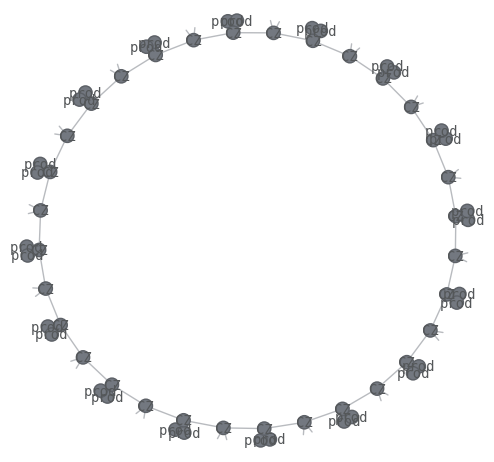

In [15]:
psi.draw()

Looks good. Weird, but good.

## Symmetries and effective density matrices

In [16]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Z = np.array([[1,0],[0,-1]])

In [17]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

In [18]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [19]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [20]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Optimisation functions

In [21]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Extracting projectors

In [22]:
def maximize_projector_states(rho):
    # Assume's rho is a single tensor, not a tensor network.
    k_inds = [i for i in rho.inds if i.startswith('k')]
    b_inds = [i for i in rho.inds if i.startswith('b')]

    rho_flat = (
        rho
        .fuse({'k': k_inds, 'b': b_inds})
        .transpose('k', 'b')
        .data
    )

    eig_vals, eig_vecs = np.linalg.eigh(rho_flat)

    max_i = np.argmax(np.abs(eig_vals))
    score = np.abs(eig_vals[max_i])
    max_vec = eig_vecs[:, max_i]

    quimb_vec = (
        qtn.Tensor(data=max_vec, inds=['k'])
        .unfuse(
            {'k': k_inds},
            shape_map={'k': (2,)*len(k_inds)}
        )
    )

    return score, quimb_vec

In [23]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

# Test

## Left projector

In [24]:
left_rho_sites = [3]

In [25]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})).contract()

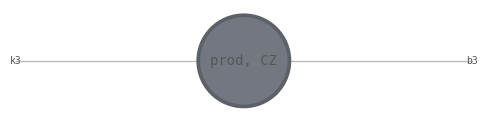

In [26]:
left_rho.draw()

In [27]:
left_score, left_proj_vec = maximize_projector_states(left_rho)

In [28]:
left_score

0.49999999999999645

In [29]:
left_sites = [1,2]
right_sites = [4,5]

In [30]:
larger_sites = left_sites + left_rho_sites + right_sites

In [31]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

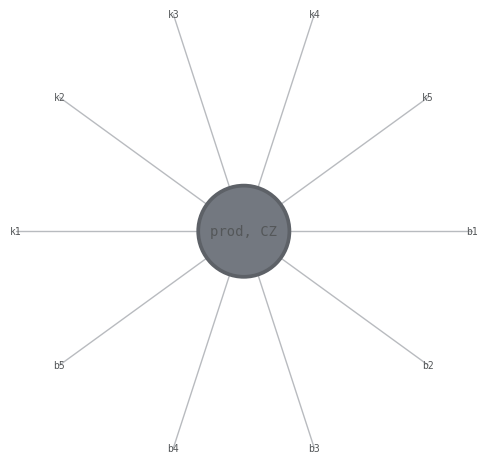

In [32]:
larger_rho.draw()

In [33]:
schmimdt_vals = projector_state_check(
    left_proj_vec,
    larger_rho,
    left_sites
)

In [34]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [35]:
left_proj_vec

Tensor(shape=(2,), inds=('k3',), tags=oset([]))

## Right projector

In [36]:
right_rho_sites = [12]

In [37]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})).contract()

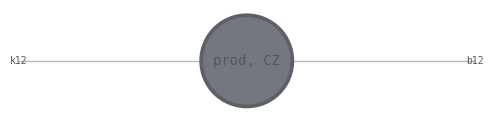

In [38]:
right_rho.draw()

In [39]:
right_score, right_proj_vec = maximize_projector_states(right_rho)

In [40]:
right_score

0.4999999999999965

In [41]:
left_sites = [10,11]
right_sites = [13,14]

In [42]:
larger_sites = left_sites + right_rho_sites + right_sites

In [43]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

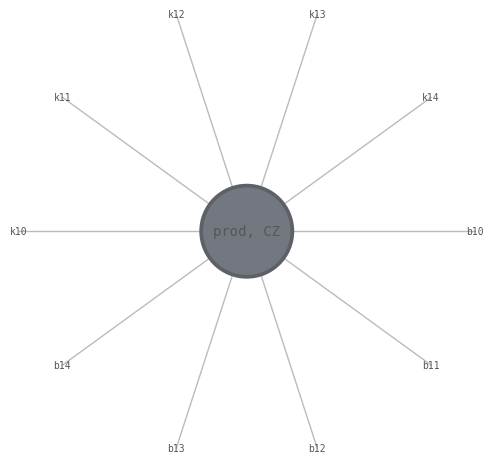

In [44]:
larger_rho.draw()

In [45]:
larger_rho

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k10', 'k11', 'k12', 'k13', 'k14', 'b10', 'b11', 'b12', 'b13', 'b14'), tags=oset(['prod', 'CZ']))

In [46]:
schmimdt_vals = projector_state_check(
    right_proj_vec,
    larger_rho,
    left_sites
)

In [47]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [48]:
proj_psi = (
    psi.reindex({'k3': 'b3', 'k12': 'b12'})
    & left_proj_vec.conj().reindex({'k3': 'b3'})
    & left_proj_vec
    & right_proj_vec.conj().reindex({'k12': 'b12'})
    & right_proj_vec
)

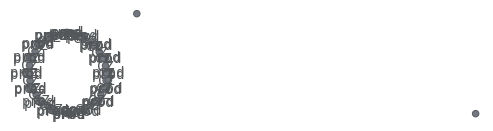

In [49]:
proj_psi.draw()

In [50]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [51]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [52]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [53]:
norm

1.0000000000000004

In [54]:
left_proj_vec

Tensor(shape=(2,), inds=('k3',), tags=oset([]))

In [55]:
right_proj_vec

Tensor(shape=(2,), inds=('k12',), tags=oset([]))

## Compute cut rho

In [56]:
cut_sites = list(range(3, 13))

In [57]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [58]:
cut_rho = (
    cut_rho_unprojected.reindex(
        {
            'k3': 'l3',
            'k12': 'l12',
            'b3': 'c3',
            'b12': 'c12',
        }
    )
    & left_proj_vec.conj().reindex({'k3': 'l3'})
    & left_proj_vec
    & left_proj_vec.reindex({'k3': 'c3'})
    & left_proj_vec.conj().reindex({'k3': 'b3'})
    & right_proj_vec.conj().reindex({'k12': 'l12'})
    & right_proj_vec
    & right_proj_vec.reindex({'k12': 'c12'})
    & right_proj_vec.conj().reindex({'k12': 'b12'})
)

In [59]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [60]:
cut_rho_trace

0.24999999999999822

In [61]:
cut_rho = cut_rho/cut_rho_trace

In [62]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

1.0000000000000009

In [63]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in cut_sites}
    | {f'b{i}': f'k{i}' for i in cut_sites}
)

In [64]:
(
    (cut_rho & cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

So the density matrix is pure, nice.

In [65]:
sub_cut_sites = list(range(4, 12))

In [66]:
sub_cut_rho = (
    cut_rho
    .reindex({'k3': 'b3', 'k12': 'b12'})
)

In [67]:
sub_cut_rho_trace = (
    sub_cut_rho
    .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
    .contract()
)

In [68]:
sub_cut_rho_trace

1.0000000000000009

In [69]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [70]:
(
    (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

## Lanczos algorithm to extract state

In [71]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [72]:
v = qtn.Tensor(
    data=random_uniform_complex((2,)*len(sub_cut_sites)),
    inds=[f'k{i}' for i in sub_cut_sites]
)

In [73]:
transpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [74]:
k_to_b_map = {f'k{i}': f'b{i}' for i in sub_cut_sites}

In [75]:
def lanczos_iteration(rho, v):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [76]:
def lanczos_algorithm(rho, v, num_iters=10):
    for _ in range(num_iters):
        v = lanczos_iteration(rho, v)

    return v

In [77]:
cut_state = lanczos_algorithm(sub_cut_rho, v)

In [78]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11'), tags=oset(['prod', 'CZ']))

In [79]:
(cut_state & cut_state.conj()).contract()

(0.9999999999999991+0j)

In [80]:
rho_state = (
    sub_cut_rho & cut_state.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
).contract()

In [81]:
(rho_state & rho_state.conj()).contract()

(1.0000000000000024+0j)

In [82]:
(cut_state & rho_state.conj()).contract()

(1.0000000000000009+0j)

Great, so outputting as we would expect.

## Check stabilizers against cut state

In [83]:
stabilizers = [
    (
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        & qu_X.reindex({'k': f'k{i+1}', 'b': f'b{i+1}'})
        & qu_Z.reindex({'k': f'k{i+2}', 'b': f'b{i+2}'})
    )
    for i in range(5, 11)
]

In [84]:
def get_expectation(psi, op):
    # Taking advantage of hermiticity, transposition invariance of op
    op_sites = [
        int(s[1:]) for s in op.outer_inds() if s.startswith('k')
    ]


    exp = qtn.TensorNetwork([
        psi,
        psi.conj().reindex({f'k{i}': f'b{i}' for i in op_sites}),
        *op
    ])

    exp = exp.contract()

    return exp

In [85]:
get_expectation(cut_state, stabilizers[0])

(0.9999999999999994+1.1752713838437418e-19j)

In [86]:
stab_expectations = [
    get_expectation(cut_state, s)
    for s in stabilizers
]

In [87]:
stabilizers[0]

TensorNetwork(tensors=3, indices=6)

In [88]:
stabilizers[1]

TensorNetwork(tensors=3, indices=6)

In [89]:
stabilizers[-1]

TensorNetwork(tensors=3, indices=6)

In [90]:
stab_expectations

[(0.9999999999999994+1.1752713838437418e-19j),
 (0.9999999999999994+1.1752713838437418e-19j),
 (0.9999999999999994+1.1752713838437418e-19j),
 (0.9999999999999994+1.1752713838437418e-19j),
 (0.9999999999999994+1.1752713838437418e-19j),
 Tensor(shape=(2, 2), inds=('k12', 'b12'), tags=oset(['prod', 'CZ']))]

In [91]:
get_expectation(cut_state, stabilizers[0])

(0.9999999999999994+1.1752713838437418e-19j)

In [92]:
get_expectation(cut_state, stabilizers[-1])

Tensor(shape=(2, 2), inds=('k12', 'b12'), tags=oset(['prod', 'CZ']))

Good, but kind of weird that the expectations are exactly the same...

### Check cut state against analytically prepared state

In [93]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [94]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [95]:
np_CZ = np.diag([1,1,1,-1])

In [96]:
np_CZ = np_CZ.reshape((2,)*4)

In [97]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [98]:
def get_cluster_state_qu_tensor_network(sites):
    # Assuming open boundary conditions here

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in sites
    ]

    leftmost_site = min(sites)
    rightmost_site = max(sites)

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(leftmost_site, rightmost_site, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)}'
        })
        for i in range(leftmost_site+1, rightmost_site, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    #out.mangle_inner_()

    out.reindex({
        f'kc_2_{leftmost_site}': f'k{leftmost_site}',
        f'kc_2_{rightmost_site}': f'k{rightmost_site}'
    },
    inplace=True)

    return out

In [99]:
sub_cut_sites

[4, 5, 6, 7, 8, 9, 10, 11]

In [100]:
comparison_state = get_cluster_state_qu_tensor_network(sub_cut_sites)

In [101]:
comparison_state

TensorNetwork(tensors=15, indices=22)

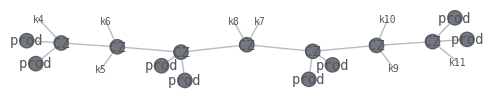

In [102]:
comparison_state.draw()

In [103]:
(comparison_state & comparison_state.conj()).contract()

0.9999999999999982

In [104]:
comparison_state.outer_inds()

('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k4', 'k11')

In [312]:
np.abs((comparison_state & cut_state.conj()).contract())

0.9999999999999991

In [311]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11'), tags=oset(['prod', 'CZ']))

In [310]:
comparison_state.outer_inds()

('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k4', 'k11')

So the cut state agrees with what we would expect analytically. Yet we see differeing results...

## Extract cut rho and EDM

In [106]:
def generate_edm_from_cut_state(cut_state, sites, symmetry_pair, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.conj().reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

### Check bare EDM

In [316]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[0],
    2
)

In [317]:
edm

Tensor(shape=(4, 4, 4, 4), inds=('k_left', 'b_left', 'k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [318]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [319]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [320]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [321]:
left_edm

Tensor(shape=(4, 4), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [322]:
right_edm = schmidt_decomp.tensors[2].isel({'v': 0})

In [323]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['k_left',],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [324]:
schmidt_decomp.tensors[1]

Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ']))

In [325]:
left_defect_sites = [4,5]
right_defect_sites = [10,11]

In [326]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [327]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [328]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [329]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j,  0.   +0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[ 0.   +0.j, -0.354-0.j],
         [ 0.   +0.j,  0.354+0.j]]],


       [[[-0.354-0.j,  0.   +0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[ 0.   +0.j,  0.354-0.j],
         [ 0.   +0.j, -0.354+0.j]]]])

In [330]:
right_fuse_maps = [
    ('k_right', [f'k{i}' for i in right_defect_sites]),
    ('b_right', [f'b{i}' for i in right_defect_sites])
]

In [331]:
right_edm = right_edm.unfuse(
    right_fuse_maps,
    shape_map = {'k_right': (2,2), 'b_right': (2,2)}
)

In [332]:
right_edm

Tensor(shape=(2, 2, 2, 2), inds=('k10', 'k11', 'b10', 'b11'), tags=oset(['prod', 'CZ']))

In [333]:
np.round(right_edm.data, 3)

array([[[[-0.354+0.j, -0.354-0.j],
         [ 0.   +0.j, -0.   -0.j]],

        [[-0.354-0.j, -0.354-0.j],
         [ 0.   +0.j, -0.   -0.j]]],


       [[[ 0.   +0.j,  0.   +0.j],
         [-0.354-0.j,  0.354+0.j]],

        [[-0.   -0.j, -0.   -0.j],
         [ 0.354+0.j, -0.354-0.j]]]])

In [334]:
def tensor_product_operators(op_1, op_2):
    out = (
        op_1[..., np.newaxis, np.newaxis]
        *op_2[np.newaxis, np.newaxis, ...]
    )

    return out

In [336]:
left_edm_check_data = (0.5)*(
    np.identity(4).reshape(2,2,2,2)
    + tensor_product_operators(np_X, np_Z)
)
left_edm_check = qtn.Tensor(
    data=left_edm_check_data,
    inds=['k4', 'b4', 'k5', 'b5']
)

left_edm_check.transpose(*left_edm.inds)

left_edm_check.data

array([[[[ 0.5,  0. ],
         [ 0. ,  0. ]],

        [[ 0.5,  0.5],
         [ 0. , -0.5]]],


       [[[ 0.5,  0. ],
         [ 0.5, -0.5]],

        [[ 0. ,  0. ],
         [ 0. ,  0.5]]]])

This looks different...

In [337]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['k4', 'b4'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [338]:
edm_1 = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[0],
    2
)

edm_2 = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[1],
    2
)

In [339]:
np.linalg.norm(edm_1.data - edm_2.data)

0.707106781186547

Compute $\rho_L$ manually.

In [340]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11'), tags=oset(['prod', 'CZ']))

In [341]:
rho_L = (
    cut_state
    & cut_state.conj().reindex({'k4': 'b4', 'k5': 'b5'})
)

rho_L = rho_L.contract()

In [342]:
rho_L

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [343]:
np.round(rho_L.data, 3)

array([[[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [-0.  +0.j, -0.25+0.j]]],


       [[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[ 0.  +0.j, -0.25+0.j],
         [ 0.  +0.j,  0.25+0.j]]]])

So the calculation is right! Is there something wrong with the state?

In [344]:
cut_sites

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [345]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11'), tags=oset(['prod', 'CZ']))

In [346]:
rho_2_site = (
    cut_state
    & cut_state.conj().reindex({'k4': 'b4', 'k5': 'b5'})
)

rho_2_site = rho_2_site.contract()

In [347]:
rho_2_site

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [348]:
np.round(rho_2_site.data, 3)

array([[[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[-0.  +0.j,  0.25+0.j],
         [-0.  +0.j, -0.25+0.j]]],


       [[[ 0.25+0.j, -0.  +0.j],
         [ 0.25+0.j,  0.  +0.j]],

        [[ 0.  +0.j, -0.25+0.j],
         [ 0.  +0.j,  0.25+0.j]]]])

In [349]:
rho_2_site = (
    comparison_state
    & comparison_state.conj().reindex({'k4': 'b4', 'k5': 'b5'})
)

rho_2_site = rho_2_site.contract()

In [350]:
rho_2_site

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [351]:
np.round(rho_2_site.data, 3)

array([[[[ 0.25, -0.  ],
         [ 0.25,  0.  ]],

        [[-0.  ,  0.25],
         [-0.  , -0.25]]],


       [[[ 0.25, -0.  ],
         [ 0.25,  0.  ]],

        [[ 0.  , -0.25],
         [ 0.  ,  0.25]]]])

And this is the identity that we're expecting. So our understanding of the state is wrong!
Compute $\rho_L$ analytically.

In [352]:
left_proj_vec

Tensor(shape=(2,), inds=('k3',), tags=oset([]))

In [353]:
right_proj_vec

Tensor(shape=(2,), inds=('k12',), tags=oset([]))

In [354]:
schmidt_decomp.tensors[1]

Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ']))

In [355]:
sites = sub_cut_sites
symmetry_pair = symmetry_actions[1]
num_defect_sites = 2

In [356]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [357]:
left_defect_op, right_defect_op = defect_ops_out[0]

In [358]:
left_defect_op = left_defect_op.unfuse(
    left_fuse_maps,
    shape_map={'k_left': [2,2], 'b_left': [2,2]}
)

In [359]:
np.round(left_defect_op.data, 3)

array([[[[ 0.045+0.998j,  0.   -0.j   ],
         [ 0.034-0.002j,  0.   -0.j   ]],

        [[ 0.   -0.j   , -0.1  +0.018j],
         [-0.   +0.j   , -0.18 -0.978j]]],


       [[[ 0.034-0.002j, -0.   -0.j   ],
         [ 0.045+0.998j, -0.   -0.j   ]],

        [[ 0.   -0.j   , -0.18 -0.978j],
         [-0.   +0.j   , -0.1  +0.018j]]]])

#### Move to $\ket{}_X \otimes \ket{}_Z$ basis

In [360]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])
np_down_X_state = 1/(np.sqrt(2))*np.array([1,-1])

np_up_Z_state = np.array([1,0])
np_down_Z_state = np.array([0,1])

In [361]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',)
)

qu_down_X_state = qtn.Tensor(
    data=np_down_X_state,
    inds=('k',)
)

qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',)
)

qu_down_Z_state = qtn.Tensor(
    data=np_down_Z_state,
    inds=('k',)
)

basis_states = [
    (qu_up_X_state, qu_up_Z_state),
    (qu_down_X_state, qu_down_Z_state),
    (qu_up_X_state, qu_down_Z_state),
    (qu_down_X_state, qu_up_Z_state)
]

In [362]:
new_basis_left_defect_op = np.zeros((4,4), dtype=complex)

for i1, (s11, s12) in enumerate(basis_states):
    for i2, (s21, s22) in enumerate(basis_states):
        out = (
            left_defect_op
            & s11.reindex({'k': 'b4'})
            & s12.reindex({'k': 'b5'})
            & s21.conj().reindex({'k': 'k4'})
            & s22.conj().reindex({'k': 'k5'})
        )

        out = out.contract()

        new_basis_left_defect_op[i1, i2] = out

In [363]:
np.round(new_basis_left_defect_op, 3)

array([[ 0.08 +0.997j, -0.   -0.j   , -0.   -0.j   , -0.   -0.j   ],
       [-0.   -0.j   ,  0.08 +0.997j, -0.   -0.j   ,  0.   +0.j   ],
       [-0.   -0.j   , -0.   -0.j   , -0.28 -0.96j ,  0.   -0.j   ],
       [-0.   +0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.011+1.j   ]])

In [364]:
np.round(np.abs(new_basis_left_defect_op), 3)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

Pretty much what we'd expect, except I thought that the bottom 2x2 matrix would be block, not just diagonal. Is there some small splitting happening...?

### $IX$ symmetry

In [365]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[1],
    2
)

In [366]:
edm.ind_size('k_left')

4

In [368]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [369]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [370]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [371]:
right_edm = schmidt_decomp.tensors[2]

In [372]:
right_edm.isel({'v': 0})

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [373]:
np.round(left_edm.data, 3)

array([[-0.354-0.j,  0.   +0.j,  0.354+0.j,  0.   +0.j],
       [ 0.   +0.j, -0.354-0.j, -0.   -0.j, -0.354-0.j],
       [-0.354-0.j,  0.   +0.j,  0.354+0.j,  0.   +0.j],
       [ 0.   +0.j,  0.354-0.j, -0.   -0.j,  0.354-0.j]])

In [374]:
left_defect_sites = [4,5]

In [375]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [376]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [377]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [378]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j,  0.   +0.j],
         [ 0.354+0.j,  0.   +0.j]],

        [[ 0.   +0.j, -0.354-0.j],
         [-0.   -0.j, -0.354-0.j]]],


       [[[-0.354-0.j,  0.   +0.j],
         [ 0.354+0.j,  0.   +0.j]],

        [[ 0.   +0.j,  0.354-0.j],
         [-0.   -0.j,  0.354-0.j]]]])

In [379]:
right_fuse_maps = [
    ('k_right', [f'k{i}' for i in right_defect_sites]),
    ('b_right', [f'b{i}' for i in right_defect_sites])
]

In [380]:
right_edm = right_edm.unfuse(
    right_fuse_maps,
    shape_map = {'k_right': (2,2), 'b_right': (2,2)}
)

In [381]:
right_edm

Tensor(shape=(1, 2, 2, 2, 2), inds=('v', 'k10', 'k11', 'b10', 'b11'), tags=oset(['prod', 'CZ']))

In [382]:
np.round(right_edm.data, 3)

array([[[[[-0.354+0.j, -0.354-0.j],
          [ 0.   +0.j, -0.   -0.j]],

         [[-0.354-0.j, -0.354-0.j],
          [ 0.   +0.j, -0.   -0.j]]],


        [[[ 0.   +0.j,  0.   +0.j],
          [-0.354-0.j,  0.354+0.j]],

         [[-0.   -0.j, -0.   -0.j],
          [ 0.354+0.j, -0.354-0.j]]]]])

In [383]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [384]:
defect_ops_out[1][-1]

0.999999999999999

In [385]:
left_defect_op, right_defect_op = defect_ops_out[0]

In [386]:
left_defect_op = left_defect_op.unfuse(
    left_fuse_maps,
    shape_map={'k_left': [2,2], 'b_left': [2,2]}
)

In [388]:
new_basis_left_defect_op = np.zeros((4,4), dtype=complex)

for i1, (s11, s12) in enumerate(basis_states):
    for i2, (s21, s22) in enumerate(basis_states):
        out = (
            left_defect_op.reindex({'k4': 'i4'})
            & qu_Z.reindex({'b': 'i4', 'k': 'k4'})
            & s11.reindex({'k': 'b4'})
            & s12.reindex({'k': 'b5'})
            & s21.conj().reindex({'k': 'k4'})
            & s22.conj().reindex({'k': 'k5'})
        )

        out = out.contract()

        new_basis_left_defect_op[i1, i2] = out

In [389]:
np.round(new_basis_left_defect_op, 3)

array([[ 0.146+0.989j,  0.   -0.j   ,  0.   -0.j   , -0.   +0.j   ],
       [-0.   -0.j   , -0.989+0.146j, -0.   +0.j   , -0.   -0.j   ],
       [ 0.   +0.j   ,  0.   +0.j   , -0.692-0.722j,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   +0.j   ,  0.   +0.j   , -0.692-0.722j]])

In [390]:
np.round(np.abs(new_basis_left_defect_op), 3)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [392]:
np.round((
    (
        left_edm.reindex({'b4': 'i4', 'b5': 'i5'})
        & qu_X.reindex({'b': 'i4', 'k': 'b4'})
        & qu_Z.reindex({'b': 'i5', 'k': 'b5'})
    )
    .contract()
    .data
), 3)

array([[[[ 0.354+0.j, -0.   -0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[-0.   -0.j,  0.354+0.j],
         [ 0.   +0.j,  0.354+0.j]]],


       [[[ 0.354+0.j, -0.   -0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[-0.   -0.j, -0.354+0.j],
         [ 0.   +0.j, -0.354+0.j]]]])

Off from what we would expect...

In [393]:
np.round((
    (
        left_edm.reindex({'b4': 'i4', 'b5': 'i5'})
        & qu_Z.reindex({'b': 'i4', 'k': 'b4'})
        & qu_I.reindex({'b': 'i5', 'k': 'b5'})
    )
    .contract()
    .data
), 3)

array([[[[-0.354-0.j,  0.   +0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[ 0.   +0.j, -0.354-0.j],
         [ 0.   +0.j,  0.354+0.j]]],


       [[[-0.354-0.j,  0.   +0.j],
         [-0.354-0.j, -0.   -0.j]],

        [[ 0.   +0.j,  0.354-0.j],
         [ 0.   +0.j, -0.354+0.j]]]])

What we expect.

### $XI$ symmetry

In [395]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[2],
    2
)

In [396]:
edm.ind_size('k_left')

4

In [397]:
np.round(edm.data, 3)

array([[[[ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [-0.   -0.j,  0.   +0.j,  0.062+0.j,  0.062+0.j],
         [ 0.   +0.j, -0.   -0.j, -0.062-0.j, -0.062-0.j]],

        [[ 0.   +0.j, -0.   -0.j,  0.   -0.j,  0.   -0.j],
         [ 0.   +0.j, -0.   -0.j,  0.   -0.j,  0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   +0.j,  0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   -0.j, -0.   -0.j]],

        [[ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [-0.   -0.j,  0.   +0.j,  0.062+0.j,  0.062+0.j],
         [ 0.   +0.j, -0.   -0.j, -0.062-0.j, -0.062-0.j]],

        [[-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   -0.j, -0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   +0.j,  0.   +0.j]]],


       [[[ 0.   +0.j, -0.   -0.j,  0.   -0.j, 

In [398]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [399]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [400]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [401]:
right_edm = schmidt_decomp.tensors[2]

In [402]:
right_edm.isel({'v': 0})

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [403]:
np.round(left_edm.data, 3)

array([[-0.354-0.j, -0.   -0.j, -0.354-0.j,  0.   +0.j],
       [-0.   -0.j, -0.354-0.j, -0.   -0.j,  0.354+0.j],
       [-0.354-0.j, -0.   -0.j, -0.354-0.j,  0.   +0.j],
       [-0.   -0.j,  0.354-0.j, -0.   -0.j, -0.354+0.j]])

In [404]:
left_defect_sites = [4,5]

In [405]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [406]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [407]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [408]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j, -0.   -0.j],
         [-0.354-0.j,  0.   +0.j]],

        [[-0.   -0.j, -0.354-0.j],
         [-0.   -0.j,  0.354+0.j]]],


       [[[-0.354-0.j, -0.   -0.j],
         [-0.354-0.j,  0.   +0.j]],

        [[-0.   -0.j,  0.354-0.j],
         [-0.   -0.j, -0.354+0.j]]]])

The symmetries have been inverted as we're starting on an odd site! Otherwise we're seeing what we expect.

In [409]:
right_fuse_maps = [
    ('k_right', [f'k{i}' for i in right_defect_sites]),
    ('b_right', [f'b{i}' for i in right_defect_sites])
]

In [410]:
right_edm = right_edm.unfuse(
    right_fuse_maps,
    shape_map = {'k_right': (2,2), 'b_right': (2,2)}
)

In [411]:
right_edm

Tensor(shape=(1, 2, 2, 2, 2), inds=('v', 'k10', 'k11', 'b10', 'b11'), tags=oset(['prod', 'CZ']))

In [412]:
np.round(right_edm.data, 3)

array([[[[[-0.354+0.j,  0.354+0.j],
          [ 0.   +0.j,  0.   +0.j]],

         [[-0.354-0.j,  0.354+0.j],
          [ 0.   +0.j,  0.   +0.j]]],


        [[[ 0.   +0.j, -0.   -0.j],
          [-0.354-0.j, -0.354-0.j]],

         [[-0.   -0.j,  0.   +0.j],
          [ 0.354+0.j,  0.354+0.j]]]]])

In [428]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [429]:
left_defect_op, right_defect_op = defect_ops_out[0]

In [430]:
left_defect_op = left_defect_op.unfuse(
    left_fuse_maps,
    shape_map={'k_left': [2,2], 'b_left': [2,2]}
)

In [431]:
new_basis_left_defect_op = np.zeros((4,4), dtype=complex)

for i1, (s11, s12) in enumerate(basis_states):
    for i2, (s21, s22) in enumerate(basis_states):
        out = (
            left_defect_op
            & s11.reindex({'k': 'b4'})
            & s12.reindex({'k': 'b5'})
            & s21.conj().reindex({'k': 'k4'})
            & s22.conj().reindex({'k': 'k5'})
        )

        out = out.contract()

        new_basis_left_defect_op[i1, i2] = out

In [432]:
np.round(new_basis_left_defect_op, 3)

array([[ 0.04 -0.999j, -0.   -0.j   ,  0.   -0.j   , -0.   +0.j   ],
       [-0.   -0.j   ,  0.04 -0.999j, -0.   +0.j   , -0.   +0.j   ],
       [ 0.   +0.j   , -0.   -0.j   , -0.416-0.91j ,  0.   -0.j   ],
       [ 0.   -0.j   , -0.   -0.j   , -0.   -0.j   ,  0.565-0.825j]])

In [433]:
np.round(np.abs(new_basis_left_defect_op), 3)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [434]:
new_basis_left_defect_op = np.zeros((4,4), dtype=complex)

for i1, (s11, s12) in enumerate(basis_states):
    for i2, (s21, s22) in enumerate(basis_states):
        out = (
            left_defect_op.reindex({'k4': 'i4', 'k5': 'i5'})
            & qu_X.reindex({'b': 'i4', 'k': 'k4'})
            & qu_Z.reindex({'b': 'i5', 'k': 'k5'})
            & s11.reindex({'k': 'b4'})
            & s12.reindex({'k': 'b5'})
            & s21.conj().reindex({'k': 'k4'})
            & s22.conj().reindex({'k': 'k5'})
        )

        out = out.contract()

        new_basis_left_defect_op[i1, i2] = out

In [435]:
np.round(new_basis_left_defect_op, 3)

array([[ 0.04 -0.999j, -0.   -0.j   , -0.   +0.j   ,  0.   -0.j   ],
       [-0.   -0.j   ,  0.04 -0.999j,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.   +0.j   , -0.   -0.j   ,  0.416+0.91j , -0.   +0.j   ],
       [ 0.   -0.j   , -0.   -0.j   ,  0.   +0.j   , -0.565+0.825j]])

In [436]:
np.round(np.abs(new_basis_left_defect_op), 3)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

### $XX$ symmetry

In [451]:
edm = generate_edm_from_cut_state(
    cut_state,
    sub_cut_sites,
    symmetry_actions[3],
    2
)

In [452]:
edm.ind_size('k_left')

4

In [453]:
np.round(edm.data, 3)

array([[[[-0.062-0.j,  0.062+0.j,  0.   +0.j,  0.   +0.j],
         [-0.062-0.j,  0.062+0.j,  0.   +0.j,  0.   +0.j],
         [ 0.   +0.j, -0.   -0.j, -0.062-0.j, -0.062-0.j],
         [-0.   -0.j,  0.   +0.j,  0.062+0.j,  0.062+0.j]],

        [[-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   -0.j, -0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   +0.j,  0.   +0.j]],

        [[ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [ 0.062+0.j, -0.062-0.j, -0.   -0.j, -0.   -0.j],
         [-0.   -0.j,  0.   +0.j,  0.062+0.j,  0.062+0.j],
         [ 0.   +0.j, -0.   -0.j, -0.062-0.j, -0.062-0.j]],

        [[-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   -0.j,  0.   +0.j, -0.   +0.j, -0.   +0.j],
         [-0.   +0.j,  0.   -0.j, -0.   -0.j, -0.   -0.j],
         [ 0.   -0.j, -0.   +0.j,  0.   +0.j,  0.   +0.j]]],


       [[[-0.   -0.j,  0.   +0.j, -0.   +0.j, 

In [454]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='v'
)

In [455]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

In [456]:
left_edm = schmidt_decomp.tensors[0].isel({'v': 0})

In [457]:
right_edm = schmidt_decomp.tensors[2]

In [458]:
right_edm.isel({'v': 0})

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [459]:
np.round(left_edm.data, 3)

array([[-0.354-0.j, -0.   -0.j,  0.354+0.j, -0.   -0.j],
       [-0.   -0.j, -0.354-0.j,  0.   +0.j, -0.354-0.j],
       [-0.354-0.j, -0.   -0.j,  0.354+0.j, -0.   -0.j],
       [-0.   -0.j,  0.354-0.j,  0.   +0.j,  0.354-0.j]])

In [460]:
left_defect_sites = [4,5]

In [461]:
left_fuse_maps = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]

In [462]:
left_edm = left_edm.unfuse(
    left_fuse_maps,
    shape_map = {'k_left': (2,2), 'b_left': (2,2)}
)

In [463]:
left_edm

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'b4', 'b5'), tags=oset(['prod', 'CZ']))

In [464]:
np.round(left_edm.data, 3)

array([[[[-0.354-0.j, -0.   -0.j],
         [ 0.354+0.j, -0.   -0.j]],

        [[-0.   -0.j, -0.354-0.j],
         [ 0.   +0.j, -0.354-0.j]]],


       [[[-0.354-0.j, -0.   -0.j],
         [ 0.354+0.j, -0.   -0.j]],

        [[-0.   -0.j,  0.354-0.j],
         [ 0.   +0.j,  0.354-0.j]]]])

Agrees with $E(IX)$ as expected.

## SPT extraction functions

In [534]:
edms = [
    generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        s,
        num_defect_sites
    )
    for s in symmetry_actions[1:]
]

In [535]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

In [536]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [537]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [538]:
e, a, b, c = symmetry_labels

In [539]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [540]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [541]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [605]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
        if label == symmetry_label
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [543]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [544]:
left_defect_sites = [4,5]
right_defect_sites = [10,11]

In [545]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
left_fuse_map = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]
left_rdm.fuse(left_fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
right_fuse_map = [
    ('k_right', [f'k{i}' for i in right_defect_sites]),
    ('b_right', [f'b{i}' for i in right_defect_sites])
]
right_rdm.fuse(right_fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [546]:
left_rdm

Tensor(shape=(4, 4), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [547]:
right_rdm

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [548]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [549]:
left_unitaries

(Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([])))

In [550]:
left_fuse_map

[('k_left', ['k4', 'k5']), ('b_left', ['b4', 'b5'])]

In [551]:
left_defect_op = left_unitaries[0].unfuse(
    left_fuse_map,
    shape_map={'k_left': [2,2], 'b_left': [2,2]}
)

In [552]:
left_decomp = qtn.tensor_core.tensor_split(
    left_defect_op,
    left_inds=['k5', 'b5'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [553]:
left_decomp.tensors[1]

Tensor(shape=(2,), inds=('vRV',), tags=oset([]))

Well approximated as disentangled.

In [554]:
left_decomp = left_decomp.isel({'vRV': 0})

In [555]:
left_decomp.tensors[0]

Tensor(shape=(2, 2), inds=('k5', 'b5'), tags=oset([]))

In [556]:
np.round(left_decomp.tensors[0].data, 3)

array([[-0.675-0.212j, -0.   -0.j   ],
       [ 0.   +0.j   , -0.675-0.212j]])

In [557]:
np.round(left_decomp.tensors[2].data, 3)

array([[ 0.707+0.j, -0.   +0.j],
       [-0.   -0.j, -0.707-0.j]])

In [558]:
left_unitaries[0]

Tensor(shape=(4, 4), inds=('b_left', 'k_left'), tags=oset([]))

In [559]:
np.round(left_unitaries[0].data, 3)

array([[-0.864-0.271j,  0.   +0.j   ,  0.127-0.404j,  0.   +0.j   ],
       [-0.   +0.j   , -0.864-0.271j, -0.   -0.j   , -0.127+0.404j],
       [-0.127+0.404j, -0.   -0.j   ,  0.864+0.271j, -0.   -0.j   ],
       [ 0.   +0.j   ,  0.127-0.404j,  0.   +0.j   ,  0.864+0.271j]])

In [560]:
np.round(left_unitaries[1].data, 3)

array([[-0.019+0.163j,  0.   +0.j   ,  0.98 +0.114j,  0.   +0.j   ],
       [-0.   +0.j   ,  0.916-0.106j, -0.   +0.j   , -0.045-0.384j],
       [ 0.98 +0.114j,  0.   +0.j   , -0.019+0.163j,  0.   +0.j   ],
       [-0.   +0.j   , -0.045-0.384j, -0.   -0.j   ,  0.916-0.106j]])

In [561]:
np.round(left_unitaries[2].data, 3)

array([[-0.659+0.351j, -0.   +0.j   ,  0.313+0.587j, -0.   +0.j   ],
       [ 0.   -0.j   , -0.496+0.851j,  0.   -0.j   , -0.15 -0.087j],
       [-0.313-0.587j, -0.   -0.j   ,  0.659-0.351j, -0.   -0.j   ],
       [ 0.   +0.j   ,  0.15 +0.087j, -0.   +0.j   ,  0.496-0.851j]])

In [612]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [613]:
left_phases

array([-0.62047807+0.78422379j,  0.62047807-0.78422379j,
        0.72743997-0.68617132j, -0.72743997+0.68617132j,
       -0.10718633-0.99423895j,  0.10718633+0.99423895j])

In [614]:
np.abs(left_phases)

array([1., 1., 1., 1., 1., 1.])

In [615]:
left_phases[::2]/left_phases[1::2]

array([-1.-8.70663314e-17j, -1.-0.00000000e+00j, -1.+5.51913488e-17j])

In [566]:
np.round(right_unitaries[0].data, 3)

array([[-0.78 +0.479j,  0.043+0.197j,  0.245+0.032j,  0.245+0.032j],
       [ 0.043+0.197j, -0.78 +0.479j, -0.245-0.032j, -0.245-0.032j],
       [-0.22 -0.112j,  0.22 +0.112j, -0.628-0.011j,  0.109-0.687j],
       [-0.22 -0.112j,  0.22 +0.112j,  0.109-0.687j, -0.628-0.011j]])

In [567]:
np.round(right_unitaries[1].data, 3)

array([[ 0.771-0.125j,  0.189-0.153j, -0.395+0.094j, -0.395+0.094j],
       [-0.189+0.153j, -0.771+0.125j, -0.395+0.094j, -0.395+0.094j],
       [ 0.405+0.034j, -0.405-0.034j,  0.766-0.196j, -0.195+0.082j],
       [-0.405-0.034j,  0.405+0.034j,  0.195-0.082j, -0.766+0.196j]])

In [568]:
np.round(right_unitaries[2].data, 3)

array([[ 0.268+0.058j,  0.079+0.881j, -0.263+0.053j, -0.263+0.053j],
       [-0.079-0.881j, -0.268-0.058j, -0.263+0.053j, -0.263+0.053j],
       [ 0.072-0.258j, -0.072+0.258j,  0.59 +0.405j,  0.244-0.533j],
       [-0.072+0.258j,  0.072-0.258j, -0.244+0.533j, -0.59 -0.405j]])

In [608]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [609]:
right_phases

array([-0.62047807-0.78422379j,  0.62047807+0.78422379j,
        0.72743997+0.68617132j, -0.72743997-0.68617132j,
       -0.10718633+0.99423895j,  0.10718633-0.99423895j])

In [610]:
np.abs(right_phases)

array([1., 1., 1., 1., 1., 1.])

In [611]:
right_phases[::2]/right_phases[1::2]

array([-1.+8.70663314e-17j, -1.-8.07620608e-17j, -1.+1.37978372e-17j])

Invariants are totally wrong, shoot.

# Conclusions
It works!

# Old code

## Computing entropies and quantum informaton

In [239]:
def compute_sub_entropy(rho, sub_sites):
    # Assuming rho is a tensor
    sites = [int(i[1:]) for i in rho.inds if i.startswith('b')]
    contract_map = {
        f'b{i}': f'k{i}' for i in sites
        if i not in sub_sites
    }
    sub_rho = (
        rho
        .reindex(contract_map)
        .contract()
        .tranpspose(
            [f'k{i}' for i in sub_sites]
            + [f'b{i}' for i in sub_sites]
        )
        .fuse({
            'k': [f'k{i}' for i in sub_sites],
            'b': [f'b{i}' for i in sub_sites]
        })
        .data
    )

    out = qu.calc.entropy(sub_rho)

    return out

# Larger system, 4 site defect operators

## Left projector

In [169]:
left_rho_sites = [4]

In [170]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})).contract()

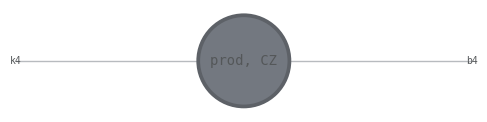

In [171]:
left_rho.draw()

In [172]:
left_score, left_proj_vec = maximize_projector_states(left_rho)

In [173]:
left_score

0.49999999999999645

In [174]:
left_sites = [2,3]
right_sites = [5,6]

In [175]:
larger_sites = left_sites + left_rho_sites + right_sites

In [176]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

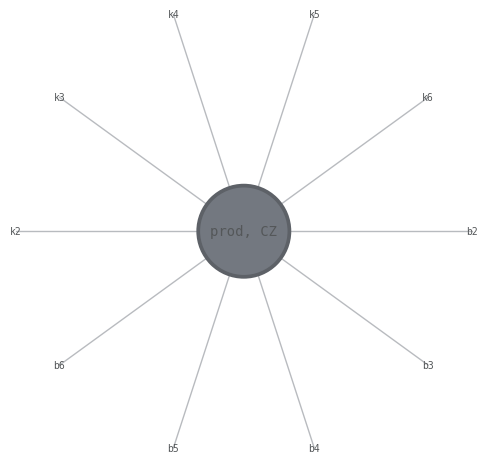

In [177]:
larger_rho.draw()

In [178]:
schmimdt_vals = projector_state_check(
    left_proj_vec,
    larger_rho,
    left_sites
)

In [179]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [180]:
left_proj_vec

Tensor(shape=(2,), inds=('k4',), tags=oset([]))

## Right projector

In [181]:
right_rho_sites = [21]

In [182]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})).contract()

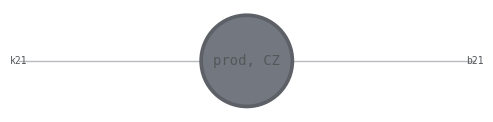

In [183]:
right_rho.draw()

In [184]:
right_score, right_proj_vec = maximize_projector_states(right_rho)

In [185]:
right_score

0.4999999999999965

In [186]:
left_sites = [19,20]
right_sites = [22,23]

In [187]:
larger_sites = left_sites + right_rho_sites + right_sites

In [188]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

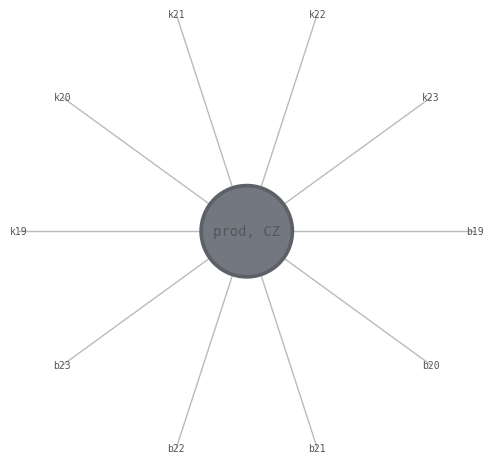

In [189]:
larger_rho.draw()

In [190]:
larger_rho

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k19', 'k20', 'k21', 'k22', 'k23', 'b19', 'b20', 'b21', 'b22', 'b23'), tags=oset(['prod', 'CZ']))

In [191]:
schmimdt_vals = projector_state_check(
    right_proj_vec,
    larger_rho,
    left_sites
)

In [192]:
schmimdt_vals

Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'CZ']))

Looks ok.

In [193]:
proj_psi = (
    psi.reindex({'k4': 'b4', 'k21': 'b21'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & left_proj_vec
    & right_proj_vec.conj().reindex({'k21': 'b21'})
    & right_proj_vec
)

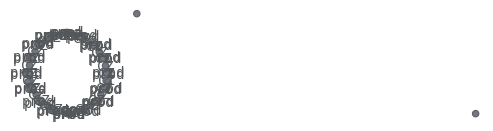

In [194]:
proj_psi.draw()

In [195]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [196]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [197]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [198]:
norm

1.0

## Compute cut rho

In [199]:
cut_sites = list(range(4, 22))

In [200]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [201]:
cut_rho = (
    cut_rho_unprojected.reindex(
        {
            'k4': 'l4',
            'k21': 'l21',
            'b4': 'c4',
            'b21': 'c21',
        }
    )
    & left_proj_vec.conj().reindex({'k4': 'l4'})
    & left_proj_vec
    & left_proj_vec.reindex({'k4': 'c4'})
    & left_proj_vec.conj().reindex({'k4': 'b4'})
    & right_proj_vec.conj().reindex({'k21': 'l21'})
    & right_proj_vec
    & right_proj_vec.reindex({'k21': 'c21'})
    & right_proj_vec.conj().reindex({'k21': 'b21'})
)

In [202]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [203]:
cut_rho_trace

0.24999999999999822

In [204]:
cut_rho = cut_rho/cut_rho_trace

In [205]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

1.000000000000001

In [206]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in cut_sites}
    | {f'b{i}': f'k{i}' for i in cut_sites}
)

In [207]:
(
    (cut_rho & cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

So the density matrix is pure, nice.

In [208]:
sub_cut_sites = list(range(5, 21))

In [209]:
sub_cut_rho = (
    cut_rho
    .reindex({'k4': 'b4', 'k21': 'b21'})
)

In [210]:
sub_cut_rho_trace = (
    sub_cut_rho
    .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
    .contract()
)

In [211]:
sub_cut_rho_trace

1.000000000000001

In [212]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [213]:
(
    (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
    .contract()
)

1.000000000000002

## Lanczos algorithm to extract state

In [214]:
v = qtn.Tensor(
    data=random_uniform_complex((2,)*len(sub_cut_sites)),
    inds=[f'k{i}' for i in sub_cut_sites]
)

In [215]:
transpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [216]:
k_to_b_map = {f'k{i}': f'b{i}' for i in sub_cut_sites}

In [217]:
cut_state = lanczos_algorithm(sub_cut_rho, v)

In [218]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20'), tags=oset(['prod', 'CZ']))

In [219]:
(cut_state & cut_state.conj()).contract()

(0.9999999999999828+0j)

In [220]:
rho_state = (
    sub_cut_rho & cut_state.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
).contract()

In [221]:
(rho_state & rho_state.conj()).contract()

(0.9999999999999836+0j)

In [222]:
(cut_state & rho_state.conj()).contract()

(0.9999999999999828+0j)

Great, so outputting as we would expect.

## Extract cut rho and EDM

In [223]:
sites = sub_cut_sites
symmetry_pair = symmetry_actions[1]
num_defect_sites = 4

In [224]:
edms = [
    generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        s,
        num_defect_sites
    )
    for s in symmetry_actions[1:]
]

In [225]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

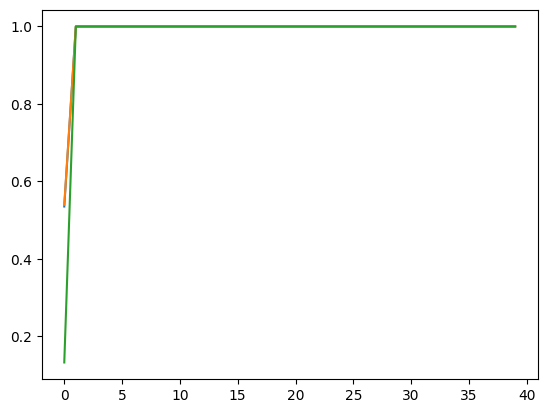

In [226]:
for l in defect_ops_results:
    plt.plot(l[1])

In [227]:
[l[1][-1] for l in defect_ops_results]

[0.9999999999999867, 0.9999999999999869, 0.9999999999999867]

In [241]:
defect_ops_results[0][0][0]

Tensor(shape=(16, 16), inds=('b_left', 'k_left'), tags=oset([]))

## SPT extraction functions

In [228]:
left_defect_sites = [5,6,7,8]
right_defect_sites = [17,18,19,20]

In [229]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [230]:
left_rdm

Tensor(shape=(16, 16), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [231]:
right_rdm

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [232]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [233]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [234]:
left_phases

array([ 0.99999119-0.00419669j,  0.0051587 +0.04347609j,
        0.92193567+0.38734302j, -0.01226066+0.04202927j,
       -0.1769656 -0.23264785j,  0.03586891-0.15095961j])

In [235]:
left_phases[::2]/left_phases[1::2]

array([2.59612117-22.69289817j, 2.59612117-22.69289817j,
       1.19511562 -1.45623787j])

In [236]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [237]:
right_phases

array([-0.31260719-0.20147573j, -0.99999119-0.00419669j,
        0.06994328-0.09775651j,  0.09611303-0.12516619j,
        0.26282731+0.26313025j,  0.97640308+0.21595605j])

In [238]:
right_phases[::2]/right_phases[1::2]

array([0.31344997+0.20016204j, 0.76124524-0.02574417j,
       0.31344997+0.20016204j])